In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/placement data.csv')

In [ ]:
df.head()  #gives first 5 rows as an idea of data we are going to deal with

,cgpa,iq,placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0


In [ ]:
df

,cgpa,iq,placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0
...,...,...,...
95,4.3,200,0
96,4.4,42,0
97,6.7,182,1
98,6.3,103,1


In [ ]:
df.shape

(100, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   iq         100 non-null    int64 
 1   placement  100 non-null    object
dtypes: int64(1), object(1)
memory usage: 1.7+ KB


###### this iloc[:,1:] means we want to read the whole dataset but we need to read the data from 1st column not the zeroth column-> included in preprocessing data

In [ ]:

import matplotlib.pyplot as plt

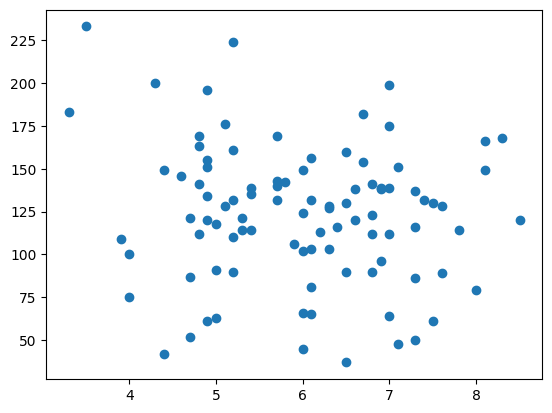

In [ ]:
plt.scatter(df['cgpa'],df['iq'])

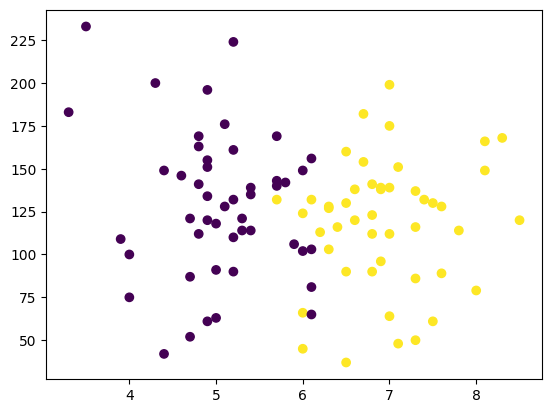

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])
# this will help us color code those persons whose placement has already been done

<p style="color:green"> Now we will have to linearly separate the ones whosoever are placed and whoever aren't placed -> we will use logistic regression because it helps in finding out a line which separates the data on the basis of few values!! </p>

In [ ]:
x=df.iloc[:,0:2]  #means only cgpa and iq columns / input column
y=df.iloc[:,-1] #means only placement column will be considered/ output column

In [ ]:
x

,cgpa,iq
0,6.8,123
1,5.9,106
2,5.3,121
3,7.4,132
4,5.8,142
...,...,...
95,4.3,200
96,4.4,42
97,6.7,182
98,6.3,103


In [ ]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
y.shape

(100,)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

# this is used to tell how much amount of data will be tested and how
# much will be trained not all data is tested only some percent of data is tested
# example out of 100 rows only 10 rows will be tested-> testing data
#training data-> 90 rows


 #here x=independent Variable (cgpa,iq) -> input
 #y= dependent variable (placement)-> output column

In [ ]:
x_train

,cgpa,iq
36,5.7,140
79,6.5,90
46,5.3,114
77,7.3,50
45,6.0,66
...,...,...
8,6.1,156
32,7.0,139
92,5.2,110
11,6.9,138


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scalar= StandardScaler()

In [ ]:
x_train = scalar.fit_transform(x_train)   #to scale down the data from -1 to +1

In [ ]:
x_train

array([[-0.30881573,  0.462944  ],
       [ 0.38902761, -0.83341444],
       [-0.65773741, -0.21116239],
       [ 1.08687096, -1.87050119],
       [-0.04712448, -1.45566649],
       [ 1.7847143 ,  0.69628852],
       [ 0.8251797 ,  1.99264696],
       [ 0.38902761,  0.20367231],
       [ 0.8251797 , -1.50752083],
       [-1.79173284, -0.57414275],
       [-0.74496782,  1.00741455],
       [ 0.04010594, -1.48159366],
       [-1.44281117,  0.69628852],
       [ 0.38902761,  0.98148738],
       [ 1.26133179, -1.58530233],
       [ 0.30179719, -0.15930805],
       [-1.0938895 ,  1.05926888],
       [-1.00665908, -1.58530233],
       [-0.91942866, -0.10745371],
       [ 0.21456678,  0.15181798],
       [ 1.08687096,  0.3851625 ],
       [ 0.04010594,  0.25552665],
       [ 1.95917514,  1.18890473],
       [ 1.34856221, -0.85934161],
       [ 0.04010594, -0.49636124],
       [ 1.08687096, -0.15930805],
       [-1.18111991, -0.0296722 ],
       [ 0.73794928,  0.43701683],
       [-2.40234577,

In [ ]:
x_test=scalar.transform(x_test)

# we have already
#fitted the data into values ranging from -1 to +1 for that
# we used fit_transform()
# but now for testing data we dont want to
#fit values once again thats why we have used transform()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
x_test

array([[  5.4, 114. ],
       [  5.2,  90. ],
       [  nan, 158. ],
       [  7. , 175. ],
       [  4.9, 151. ],
       [  3.5, 233. ],
       [  nan, 107. ],
       [  4.7,  52. ],
       [  5.7, 143. ],
       [  5.8, 142. ]])

In [ ]:
x_test

array([[  5.4, 114. ],
       [  5.2,  90. ],
       [  nan, 158. ],
       [  7. , 175. ],
       [  4.9, 151. ],
       [  3.5, 233. ],
       [  nan, 107. ],
       [  4.7,  52. ],
       [  5.7, 143. ],
       [  5.8, 142. ]])

In [ ]:
y_train

,placement
36,0
79,1
46,0
77,1
45,1
...,...
8,0
32,1
92,0
11,1


In [ ]:
y_test

,placement
41,0
28,0
91,1
52,1
89,0
50,0
81,0
94,0
6,0
4,0


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf= LogisticRegression()  #object of the class linear regression

In [ ]:
clf.fit(x_train_imputed,y_train)

LogisticRegression()

In [ ]:
clf.predict(x_test)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
y_test

,placement
41,0
28,0
91,1
52,1
89,0
50,0
81,0
94,0
6,0
4,0


In [ ]:
y_pred = clf.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
from mlxtend.plotting import plot_decision_regions

In [ ]:
plot_decision_region(x_train,y_train.values,clf= clf,legend=2)

NameError: name 'plot_decision_region' is not defined

In [ ]:
import pickle  #converts objects into file

In [ ]:
pickle.dump(clf,open("model.pkl"),"wb") #this will create a new file
# and we can directly push that file to a server for deploying

FileNotFoundError: [Errno 2] No such file or directory: 'model.pkl'

 ### <p style="color:green">
### Steps:
 0. preprocess +EDA+ feature selection
  1. Extract input and output cols
 2. scale the values
 3. train test split
 4. train the mode;
 5. evaluate the model/model selection
 6. deploy the model .
</p>

# New Section